In [34]:
#import
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pickle

In [35]:
# Load data
batting = pd.read_csv('baseball-reference data/all_batting_updated.csv')
pitching = pd.read_csv('baseball-reference data/all_pitching_updated.csv')
hof_batting = pd.read_csv('baseball-reference data/hof_batting_updated.csv')
hof_pitching = pd.read_csv('baseball-reference data/hof_pitching_updated.csv')

In [36]:
#Preprocess data

#drops invalid cols
batting = batting.drop(['IDfg','Team'],axis=1)
pitching = pitching.drop(['IDfg','Team'],axis=1)
hof_batting = hof_batting.drop('Rk',axis=1)
hof_pitching = hof_pitching.drop('Rk',axis=1)

# Label Hall of Fame players
hof_batting['HOF'] = 1
hof_pitching['HOF'] = 1

# Merge stats of all players with Hall of Fame labels
batting = batting.merge(hof_batting[['playerID', 'HOF']], on='playerID', how='left')
pitching = pitching.merge(hof_pitching[['playerID', 'HOF']], on='playerID', how='left')

# Fill missing HOF labels with 0 (not in Hall of Fame)
batting['HOF'] = batting['HOF'].fillna(0)
pitching['HOF'] = pitching['HOF'].fillna(0)

print('Batting:')
print(batting[:5])
print('\nPitching:')
print(pitching[:5])



Batting:
   Season           Name  Age    G   AB   PA    H   1B  2B  3B  ...  CStr%  \
0    2002    Barry Bonds   37  143  403  612  149   70  31   2  ...  0.127   
1    2001    Barry Bonds   36  153  476  664  156   49  32   2  ...    NaN   
2    2004    Barry Bonds   39  147  373  617  135   60  27   3  ...  0.124   
3    1946   Ted Williams   27  150  514  672  176   93  37   8  ...    NaN   
4    1956  Mickey Mantle   24  150  533  652  188  109  22   5  ...    NaN   

    CSW%  xBA  xSLG  xwOBA  L-WAR  first_name  last_name   playerID  HOF  
0  0.191  NaN   NaN    NaN   12.7       Barry      Bonds  bondsba01  0.0  
1    NaN  NaN   NaN    NaN   12.5       Barry      Bonds  bondsba01  0.0  
2  0.164  NaN   NaN    NaN   11.9       Barry      Bonds  bondsba01  0.0  
3    NaN  NaN   NaN    NaN   11.6         Ted   Williams  willite01  1.0  
4    NaN  NaN   NaN    NaN   11.5      Mickey     Mantle  mantlmi01  1.0  

[5 rows x 322 columns]

Pitching:
   Season            Name  Age   W   

In [ ]:
# Select relevant features (excluding playerID and other non-numeric columns)
batting_features = batting.select_dtypes(include=['number']).drop(columns=['HOF']).fillna(0)
pitching_features = pitching.select_dtypes(include=['number']).drop(columns=['HOF']).fillna(0)
y_batting = batting['HOF']
y_pitching = pitching['HOF']

# Apply SMOTE
smote = SMOTE(random_state=42)
X_res_b, y_res_b = smote.fit_resample(batting_features, y_batting)
X_res_p, y_res_p = smote.fit_resample(pitching_features, y_pitching)

# Stratified split
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_res_b, y_res_b, test_size=0.2, random_state=42, stratify=y_res_b)
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_res_p, y_res_p, test_size=0.2, random_state=42, stratify=y_res_p)

# Scale features
scaler = StandardScaler()

# Keep feature names when scaling
X_train_b_scaled = pd.DataFrame(scaler.fit_transform(X_train_b), columns=X_train_b.columns)
X_test_b_scaled = pd.DataFrame(scaler.transform(X_test_b), columns=X_test_b.columns)
X_train_p_scaled = pd.DataFrame(scaler.fit_transform(X_train_p), columns=X_train_p.columns)
X_test_p_scaled = pd.DataFrame(scaler.transform(X_test_p), columns=X_test_p.columns)

In [ ]:
# Train LightGBM models
batting_model = lgb.LGBMClassifier(
    objective='binary',
    metric='binary_logloss',
    n_estimators=1000,
    learning_rate=0.1,
)

pitching_model = lgb.LGBMClassifier(
    objective='binary',
    metric='binary_logloss',
    n_estimators=1000,
    learning_rate=0.1,
)

batting_model.fit(X_train_b_scaled, y_train_b)
pitching_model.fit(X_train_p_scaled, y_train_p)


# Saving models
with open("models/batting_model.pkl", "wb") as f:
    pickle.dump(batting_model, f)

with open("models/pitching_model.pkl", "wb") as f:
    pickle.dump(pitching_model, f)

In [ ]:
# Predictions
y_pred_b = batting_model.predict(X_test_b_scaled)
y_pred_p = pitching_model.predict(X_test_p_scaled)

In [ ]:
# Evaluation
print("Batting Model Performance:")
print(accuracy_score(y_test_b, y_pred_b))
print(classification_report(y_test_b, y_pred_b))

print("\nPitching Model Performance:")
print(accuracy_score(y_test_p, y_pred_p))
print(classification_report(y_test_p, y_pred_p))

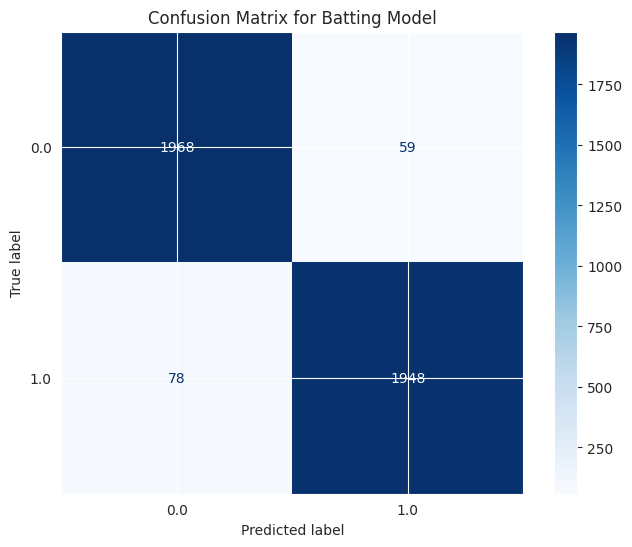

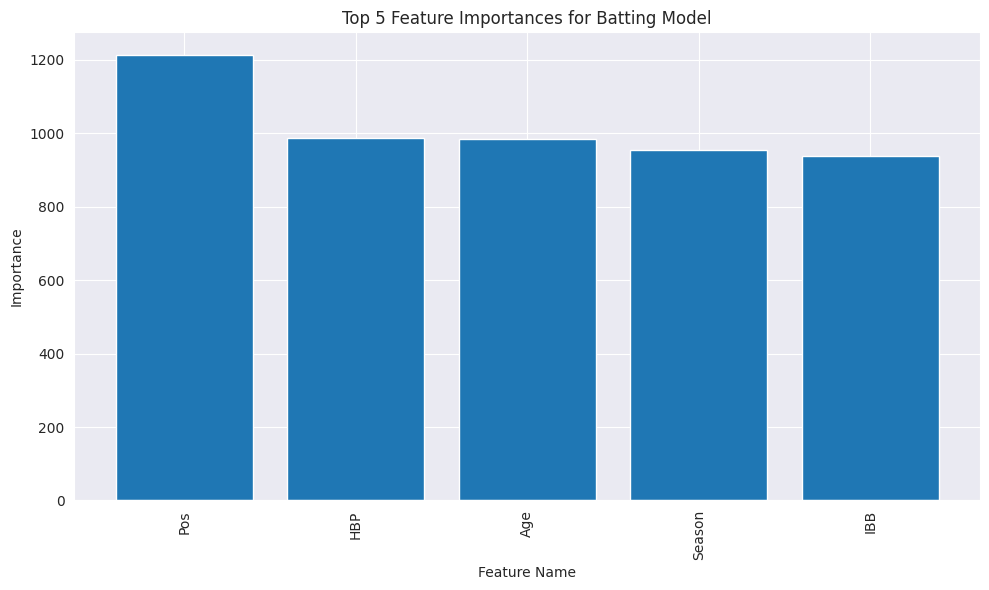

In [41]:
# Generate confusion matrix
cm_batting = confusion_matrix(y_test_b, y_pred_b)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_batting, display_labels=batting_model.classes_)
disp.plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix for Batting Model')
plt.show()

# Get feature importances
feature_importances = batting_model.feature_importances_

# Get feature names
feature_names = batting_features.columns

# Sort feature importances in descending order
sorted_importances = sorted(zip(feature_names, feature_importances), key=lambda x: x[1], reverse=True)

# Select top 5 features
top_5_features = sorted_importances[:5]

# Extract feature names and importances
top_5_names = [x[0] for x in top_5_features]
top_5_importances = [x[1] for x in top_5_features]

# Plot top 5 feature importances
plt.figure(figsize=(10, 6))
plt.bar(top_5_names, top_5_importances)
plt.title('Top 5 Feature Importances for Batting Model')
plt.xlabel('Feature Name')
plt.ylabel('Importance')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


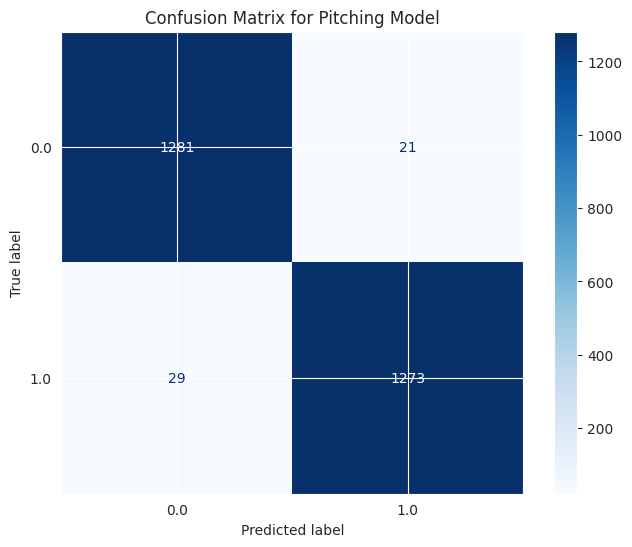

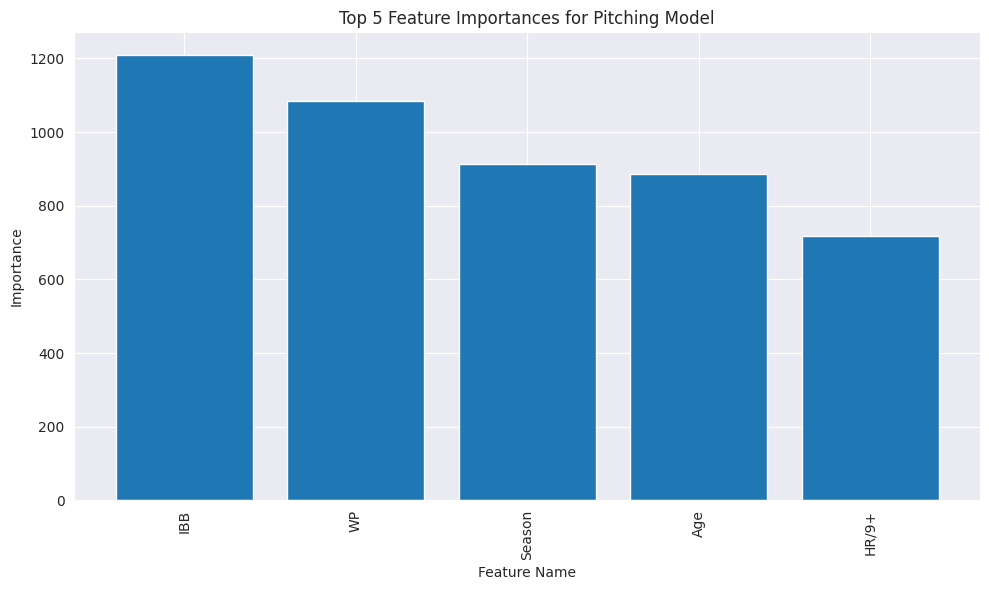

In [42]:
# Generate confusion matrix
cm_pitching = confusion_matrix(y_test_p, y_pred_p)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_pitching, display_labels=pitching_model.classes_)
disp.plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix for Pitching Model')
plt.show()

# Get feature importances
feature_importances = pitching_model.feature_importances_

# Get feature names
feature_names = pitching_features.columns

# Sort feature importances in descending order
sorted_importances = sorted(zip(feature_names, feature_importances), key=lambda x: x[1], reverse=True)

# Select top 5 features
top_5_features = sorted_importances[:5]

# Extract feature names and importances
top_5_names = [x[0] for x in top_5_features]
top_5_importances = [x[1] for x in top_5_features]

# Plot top 5 feature importances
plt.figure(figsize=(10, 6))
plt.bar(top_5_names, top_5_importances)
plt.title('Top 5 Feature Importances for Pitching Model')
plt.xlabel('Feature Name')
plt.ylabel('Importance')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
